# Multi-class Classification
Let's get started!

In [1]:
# grader-required-cell

import csv
import string
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img

2026-02-11 08:39:47.630719: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# comment this for GPU
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
devices=tf.config.experimental.list_physical_devices()
devices

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
os.makedirs("./data/sign_mnist", exist_ok=True)

In [4]:

# # sign_mnist_train.csv
# !gdown --id 1z0DkA9BytlLxO1C0BAWzknLyQmZAp0HR -O ./data/sign_mnist/sign_mnist_train.csv
# # sign_mnist_test.csv
# !gdown --id 1z1BIj4qmri59GWBG4ivMNFtpZ4AXIbzg -O ./data/sign_mnist/sign_mnist_test.csv

In [5]:
# grader-required-cell

TRAINING_FILE = './data/sign_mnist/sign_mnist_train.csv'
VALIDATION_FILE = './data/sign_mnist/sign_mnist_test.csv'

In [6]:
# grader-required-cell

with open(TRAINING_FILE) as training_file:
  line = training_file.readline()
  print(f"First line (header) looks like this:\n{line}")
  line = training_file.readline()
  print(f"Each subsequent line (data points) look like this:\n{line}")

First line (header) looks like this:
label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,pixel49,pixel50,pixel51,pixel52,pixel53,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,pixel64,pixel65,pixel66,pixel67,pixel68,pixel69,pixel70,pixel71,pixel72,pixel73,pixel74,pixel75,pixel76,pixel77,pixel78,pixel79,pixel80,pixel81,pixel82,pixel83,pixel84,pixel85,pixel86,pixel87,pixel88,pixel89,pixel90,pixel91,pixel92,pixel93,pixel94,pixel95,pixel96,pixel97,pixel98,pixel99,pixel100,pixel101,pixel102,pixel103,pixel104,pixel105,pixel106,pixel107,pixel108,pixel109,pixel110,pixel111,pixel112,pixel113,pixel114,pixel115,pixel116,pixel117,pixel118,pix

In [7]:
def parse_data_from_input(filename):
  with open(filename) as file:
    csv_reader = csv.reader(file, delimiter=',')
    next(csv_reader)
    images, labels = [],[]
    for row in csv_reader:
      labels.append(row[:1])
      images.append(row[1:])

    labels = np.array(labels, dtype='float64').reshape(-1)
    images = np.array(images, dtype='float64').reshape(-1,28,28)
    return images, labels

In [8]:
training_images, training_labels = parse_data_from_input(TRAINING_FILE)
validation_images, validation_labels = parse_data_from_input(VALIDATION_FILE)

print(f"Training images has shape: {training_images.shape} and dtype: {training_images.dtype}")
print(f"Training labels has shape: {training_labels.shape} and dtype: {training_labels.dtype}")
print(f"Validation images has shape: {validation_images.shape} and dtype: {validation_images.dtype}")
print(f"Validation labels has shape: {validation_labels.shape} and dtype: {validation_labels.dtype}")

Training images has shape: (27455, 28, 28) and dtype: float64
Training labels has shape: (27455,) and dtype: float64
Validation images has shape: (7172, 28, 28) and dtype: float64
Validation labels has shape: (7172,) and dtype: float64


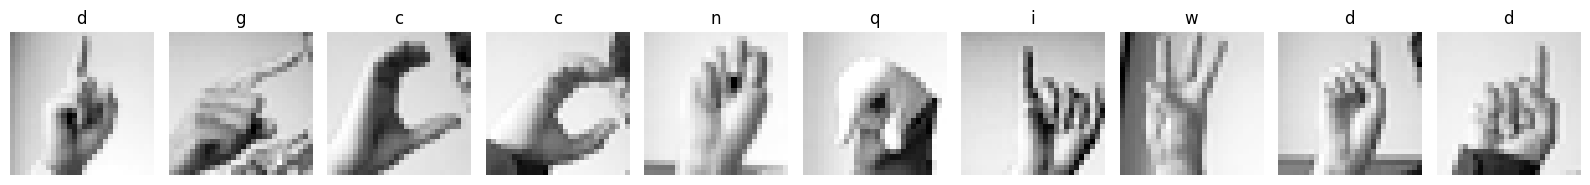

In [9]:
def plot_categories(training_images, training_labels):
  fig, axes = plt.subplots(1, 10, figsize=(16, 15))
  axes = axes.flatten()
  letters = list(string.ascii_lowercase)

  for k in range(10):
    img = training_images[k]
    img = np.expand_dims(img, axis=-1)
    img = array_to_img(img)
    ax = axes[k]
    ax.imshow(img, cmap="Greys_r")
    ax.set_title(f"{letters[int(training_labels[k])]}")
    ax.set_axis_off()

  plt.tight_layout()
  plt.show()

plot_categories(training_images, training_labels)

In [10]:
def train_val_generators(training_images, training_labels, validation_images, validation_labels):
  training_images = np.expand_dims(training_images, axis=3)
  validation_images = np.expand_dims(validation_images, axis=3)

  train_datagen = ImageDataGenerator(rescale = 1.0/255. )
  train_generator = train_datagen.flow(x=training_images,
                                       y=training_labels,
                                       batch_size=32)

  validation_datagen = ImageDataGenerator(rescale = 1.0/255. )
  validation_generator = validation_datagen.flow(x=validation_images,
                                                 y=validation_labels,
                                                 batch_size=32)

  return train_generator, validation_generator

In [ ]:
def train_val_datasets(training_images, training_labels,
                       validation_images, validation_labels,
                       batch_size=64):

    train_ds = tf.data.Dataset.from_tensor_slices(
        (training_images, training_labels)
    )

    val_ds = tf.data.Dataset.from_tensor_slices(
        (validation_images, validation_labels)
    )

    def preprocess(x, y):
        x = tf.cast(x, tf.float32) / 255.0
        return x, y

    train_ds = (
        train_ds
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .shuffle(2000)
        .batch(batch_size)
        .cache()
        .prefetch(tf.data.AUTOTUNE)
    )

    val_ds = (
        val_ds
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .cachfetch(tf.data.AUTOTUNE)
    )

    return train_ds, val_ds


In [12]:
# train_generator, validation_generator = train_val_generators(training_images, training_labels, validation_images, validation_labels)
train_generator, validation_generator = train_val_datasets(training_images, training_labels, validation_images, validation_labels)

# print(f"Images of training generator have shape: {train_generator.x.shape}")
# print(f"Labels of training generator have shape: {train_generator.y.shape}")
# print(f"Images of validation generator have shape: {validation_generator.x.shape}")
# print(f"Labels of validation generator have shape: {validation_generator.y.shape}")

2026-02-11 08:39:59.469478: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1636] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14815 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 6.0


In [13]:
def create_model():
  model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(26, activation='softmax')
  ])
  model.compile(optimizer = 'adam',
                loss = 'sparse_categorical_crossentropy',
                metrics=['accuracy'])

  return model

In [14]:

class TrainingCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if (logs.get('accuracy') > 0.95 and logs.get('val_accuracy') > 0.95):
            self.model.stop_training = True
            print("Sufficient Metrics Reached!")



In [15]:
# Save your model
from gc import callbacks


model = create_model()

# Train your model
history = model.fit(train_generator,
                    epochs=15,
                    callbacks=TrainingCallback(),
                    validation_data=validation_generator
                    )

Epoch 1/15


2026-02-11 08:40:01.521592: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8905
2026-02-11 08:40:01.787909: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x5ad8497933a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-11 08:40:01.787960: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
2026-02-11 08:40:01.795153: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-11 08:40:01.985211: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


429/429 [==============================] - 6s 9ms/step - loss: 1.2539 - accuracy: 0.6169 - val_loss: 0.5061 - val_accuracy: 0.8359
Epoch 2/15
429/429 [==============================] - 4s 9ms/step - loss: 0.1909 - accuracy: 0.9403 - val_loss: 0.3099 - val_accuracy: 0.8989
Epoch 3/15
429/429 [==============================] - 4s 8ms/step - loss: 0.0648 - accuracy: 0.9811 - val_loss: 0.2505 - val_accuracy: 0.9225
Epoch 4/15
429/429 [==============================] - 4s 9ms/step - loss: 0.0359 - accuracy: 0.9898 - val_loss: 0.3152 - val_accuracy: 0.9169
Epoch 5/15
429/429 [==============================] - 4s 9ms/step - loss: 0.0233 - accuracy: 0.9938 - val_loss: 0.2338 - val_accuracy: 0.9313
Epoch 6/15
429/429 [==============================] - 4s 9ms/step - loss: 0.0175 - accuracy: 0.9954 - val_loss: 0.3276 - val_accuracy: 0.9216
Epoch 7/15
429/429 [==============================] - 4s 8ms/step - loss: 0.0202 - accuracy: 0.9940 - val_loss: 0.2749 - val_accuracy: 0.9318
Epoch 8/15
429/42

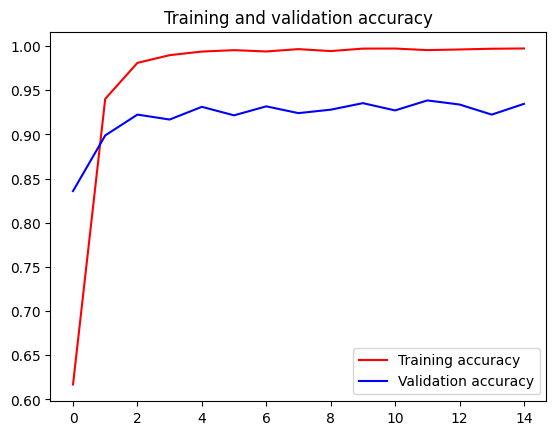

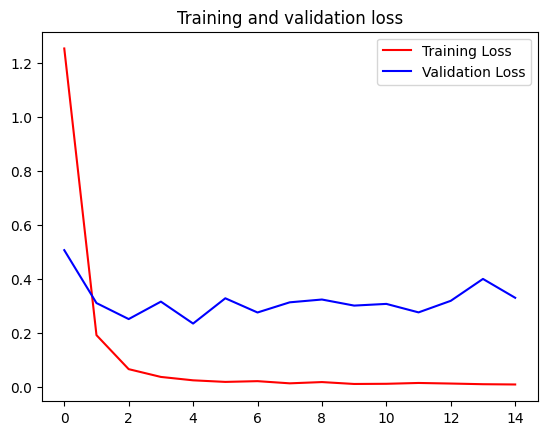

In [16]:
# Plot the chart for accuracy and loss on both training and validation
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()